In [ ]:
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression
from matplotlib import pyplot as plt
from scipy import stats

### Generate the data we will use to practice linear regression with

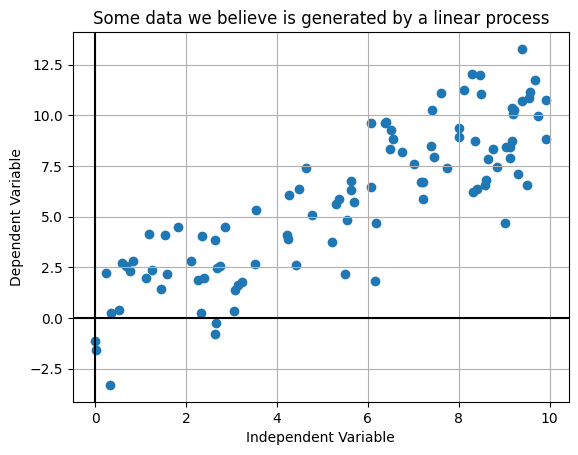

In [ ]:
rng = np.random.RandomState(1415)

def linear_function_with_noise(x, random_state):
    m = 0.9876  # The slope of the line.
    b = 0.2345  # The y-intercept of the line.

    y = m * x + b
    noise = stats.norm.rvs(loc=0, scale=2, size=y.size)

    return y + noise


x = stats.uniform.rvs(loc=0, scale=10, size=100, random_state=rng)
y = linear_function_with_noise(x, rng)

fig, ax = plt.subplots()
ax.scatter(x, y)
ax.axvline(x=0, c="k")
ax.axhline(y=0, c="k")

ax.set_title("Some data we believe is generated by a linear process")
ax.set_xlabel("Independent Variable")
ax.set_ylabel("Dependent Variable")
ax.grid()
fig.show()

### Fit a line with Seaborn's [`regplot`](https://seaborn.pydata.org/generated/seaborn.regplot.html)

<Axes: >

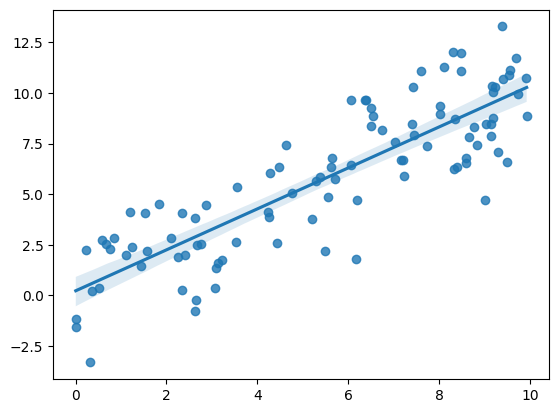

In [ ]:
sns.regplot(x=x, y=y)

### Fit a line by minimizing an objective function with a for-loop

In [ ]:
def plot_data_with_line(x, y, slope, intercept):
    fig, ax = plt.subplots()
    ax.scatter(x, y)

    y_pred = linear_model(x, slope, intercept)
    sse = sum_of_squared_errors(y, y_pred)
    R_squared = get_R_squared(y, y_pred)
    ax.plot(x, y_pred, label=f"m={slope:.4f}, b={intercept:.4f}, sse={sse:.2f}, r^2={R_squared:.3f}")

    ax.axvline(x=0, c="k")
    ax.axhline(y=0, c="k")

    ax.set_title("Some data we believe is generated by a linear process")
    ax.set_xlabel("Independent Variable")
    ax.set_ylabel("Dependent Variable")
    ax.grid()
    ax.legend(loc="upper left")
    fig.show()

I think that the data's slope and intercept is m = 1.0 and b = 0.5


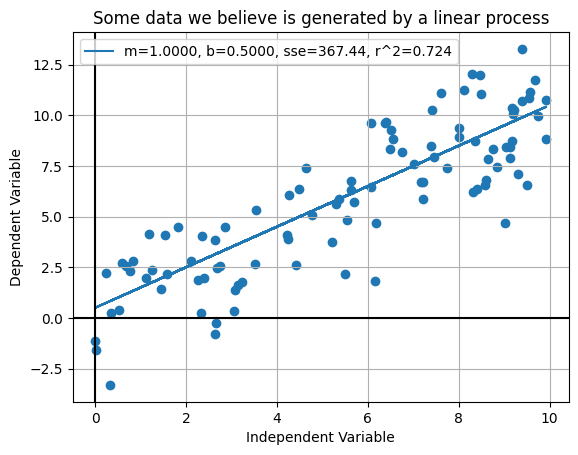

In [ ]:
def linear_model(x, slope, intercept):
    y = slope * x + intercept
    return y


def sum_of_squared_errors(y_true, y_pred):
    SSE = np.sum((y_true - y_pred)**2)
    return SSE


best_sse = 1e10
for slope in np.arange(0, 2, 0.5):
    for intercept in np.arange(-1, 1, 0.5):
        prediction = linear_model(x, slope, intercept)
        sse = sum_of_squared_errors(y, prediction)

        if sse < best_sse:
            best_sse = sse
            guess_slope = slope
            guess_intercept = intercept

print(f"I think that the data's slope and intercept is m = {guess_slope} and b = {guess_intercept}")
plot_data_with_line(x, y, guess_slope, guess_intercept)

### Fit a line NumPy's [`polyfit`](https://numpy.org/doc/stable/reference/generated/numpy.polyfit.html)

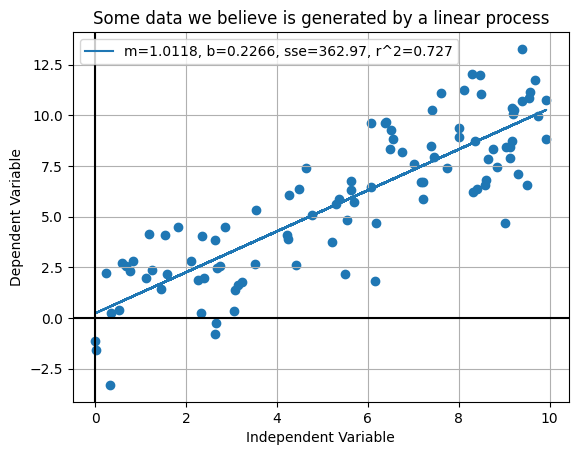

In [ ]:
numpy_slope, numpy_intercept = np.polyfit(x, y, deg=1)
plot_data_with_line(x, y, numpy_slope, numpy_intercept)

### Fit a line with scikit learn's [`LinearRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)

In [ ]:
linreg = LinearRegression()

In [ ]:
linreg

LinearRegression()

In [ ]:
linreg.fit(x.reshape(-1, 1), y)

LinearRegression()

In [ ]:
linreg.score(x.reshape(-1, 1), y)

0.7271601551944862

In [ ]:
linreg.get_params()

{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}

In [ ]:
def get_R_squared(y_true, y_pred):
    RSS = np.sum((y_true - y_pred)**2)
    TSS = np.sum((y_true - np.mean(y_true))**2)
    R_squared = 1 - RSS / TSS
    return R_squared